# **<h1 align="center">Import Libraries & Read Data</h1>**

In [1]:
!pip install clean-text[gpl]
!pip install -U transformers tensorflow
!pip install "transformers<5.0" tf-keras
!pip install sacrebleu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import tensorflow as tf

from sklearn.model_selection import train_test_split


from transformers import AutoTokenizer
from transformers import TFAutoModelForSeq2SeqLM

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from cleantext import clean

MODEL_NAME = "Helsinki-NLP/opus-mt-en-ar"
EPOCHS = 10
LEARNING_RATE = 1e-5
BATCH_SIZE = 16


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 25.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
    

In [2]:
path = "/kaggle/input/datasets/samirmoustafa/arabic-to-english-translation-sentences/ara_eng.txt"

with open(path, "r", encoding="utf-8") as file:
    lines = file.readlines()

print(lines[:10])

['Hi.\tمرحبًا.\n', 'Run!\tاركض!\n', 'Help!\tالنجدة!\n', 'Jump!\tاقفز!\n', 'Stop!\tقف!\n', 'Go on.\tداوم.\n', 'Go on.\tاستمر.\n', 'Hello!\tمرحباً.\n', 'Hurry!\tتعجّل!\n', 'Hurry!\tاستعجل!\n']


In [3]:
data = []

for line in lines:
    line = line.strip()

    if not line:
        continue

    parts = line.split("\t")

    if len(parts) >= 2:
        arabic = parts[0].strip()
        english = parts[1].strip()

        data.append([arabic, english])

df = pd.DataFrame(data, columns=["english","arabic"])

df

,english,arabic
0,Hi.,مرحبًا.
1,Run!,اركض!
2,Help!,النجدة!
3,Jump!,اقفز!
4,Stop!,قف!
...,...,...
24633,rising voices promoting a more linguistically ...,شاركنا تحدي ابداع ميم بلغتك الام تعزيزا للتنوع...
24634,following last year s successful campaign we i...,استكمالا لنجاح حملة العام السابق ندعوكم للمشار...
24635,during last year s challenge we also met langu...,تعرفنا خلال تحدي العام الماضي على ابطال لغويين...
24636,to take part just follow the simple steps outl...,للمشاركة في التحدي اتبع الخطوات الموضحة على ال...


# **<h1 align="center">Clean Text Function</h1>**

In [4]:
def basic_clean(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

df["english"] = df["english"].apply(basic_clean)
df["arabic"] = df["arabic"].apply(basic_clean)

df = df.dropna(subset=["english", "arabic"])
df = df[(df["english"].str.len() > 0) & (df["arabic"].str.len() > 0)]
df = df.drop_duplicates(subset=["english", "arabic"])

df = df[df["english"].str.lower() != df["arabic"].str.lower()]

In [5]:
def length_ratio_ok(row, min_ratio=0.3, max_ratio=3.0):
    len_en = len(row["english"])
    len_ar = len(row["arabic"])
    if len_en == 0 or len_ar == 0:
        return False
    ratio = len_en / len_ar
    return min_ratio <= ratio <= max_ratio

df = df[df.apply(length_ratio_ok, axis=1)]

print(f"Rows After Clening: {len(df)}")

Rows After Clening: 24242


# **<h1 align="center">Splitting Data</h1>**

In [6]:
X = df["english"].values
y = df["arabic"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 19393
Validation: 2424
Test: 2425


# **<h1 align="center">AutoTokenizer From Helsinki</h1>**

In [7]:
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-ar")

def encode(src_texts, tgt_texts):
    inputs = tokenizer(
        src_texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=100,
        return_tensors="np",
    )
    labels = tokenizer(
        text_target=tgt_texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=100,
        return_tensors="np",
    )
    inputs["labels"] = labels["input_ids"]
    return inputs

train_encodings = encode(X_train, y_train)
val_encodings = encode(X_val, y_val)
test_encodings = encode(X_test, y_test)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/801k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/917k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


# **<h1 align="center">Model Architecture</h1>**

In [8]:
def build_tf_dataset(encodings, batch_size, shuffle=False):
    features = {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
    }
    labels = encodings["labels"]
 
    # Replace pad token id (0) with -100 in labels so the loss ignores padding
    labels = np.where(labels == 0, -100, labels)
 
    dataset = tf.data.Dataset.from_tensor_slices((features, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(labels))
    dataset = dataset.batch(batch_size)
    return dataset
 
 
train_dataset = build_tf_dataset(train_encodings, BATCH_SIZE, shuffle=True)
val_dataset = build_tf_dataset(val_encodings, BATCH_SIZE, shuffle=False)
test_dataset = build_tf_dataset(test_encodings, BATCH_SIZE, shuffle=False)

I0000 00:00:1786809159.714433      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
model = TFAutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model.summary()

tf_model.h5:   0%|          | 0.00/308M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFMarianMTModel.

All the layers of TFMarianMTModel were initialized from the model checkpoint at Helsinki-NLP/opus-mt-en-ar.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFMarianMTModel for predictions without further training.


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Model: "tf_marian_mt_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model (TFMarianMainLayer)   multiple                  76817408  
                                                                 
 final_logits_bias (BiasLay  multiple                  62802     
 er)                                                             
                                                                 
Total params: 76880210 (293.27 MB)
Trainable params: 76817408 (293.04 MB)
Non-trainable params: 62802 (245.32 KB)
_________________________________________________________________


# **<h1 align="center">Model Architecture</h1>**

## **Compile & Callbacks**

In [10]:
class HFModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, save_dir, tokenizer, monitor="val_loss", mode="min"):
        super().__init__()
        self.save_dir = save_dir
        self.tokenizer = tokenizer
        self.monitor = monitor
        self.mode = mode
        self.best = np.inf if mode == "min" else -np.inf
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
 
        improved = (current < self.best) if self.mode == "min" else (current > self.best)
        if improved:
            self.best = current
            self.model.save_pretrained(self.save_dir)
            self.tokenizer.save_pretrained(self.save_dir)
            print(f"\nEpoch {epoch + 1}: {self.monitor} improved to {current:.4f} — "
                  f"full model saved to '{self.save_dir}'")

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, metrics=["accuracy"])

hf_checkpoint = HFModelCheckpoint(
    save_dir="finetuned-opus-mt-en-ar",
    tokenizer=tokenizer,
    monitor="val_loss",
    mode="min",
)
 
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    hf_checkpoint,
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

## Model Train

In [12]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10


I0000 00:00:1786809211.171804     102 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1213/1213 [==============================] - ETA: 0s - loss: 2.8335 - accuracy: 0.1032

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:461: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[62801]]}
  warnings.warn(



Epoch 1: val_loss improved to 2.5044 — full model saved to 'finetuned-opus-mt-en-ar'
1213/1213 [==============================] - 476s 340ms/step - loss: 2.8335 - accuracy: 0.1032 - val_loss: 2.5044 - val_accuracy: 0.1133 - lr: 1.0000e-05
Epoch 2/10
1213/1213 [==============================] - ETA: 0s - loss: 2.4775 - accuracy: 0.1128
Epoch 2: val_loss improved to 2.4075 — full model saved to 'finetuned-opus-mt-en-ar'
1213/1213 [==============================] - 407s 335ms/step - loss: 2.4775 - accuracy: 0.1128 - val_loss: 2.4075 - val_accuracy: 0.1164 - lr: 1.0000e-05
Epoch 3/10
1213/1213 [==============================] - ETA: 0s - loss: 2.2785 - accuracy: 0.1183
Epoch 3: val_loss improved to 2.3616 — full model saved to 'finetuned-opus-mt-en-ar'
1213/1213 [==============================] - 407s 335ms/step - loss: 2.2785 - accuracy: 0.1183 - val_loss: 2.3616 - val_accuracy: 0.1177 - lr: 1.0000e-05
Epoch 4/10
1213/1213 [==============================] - ETA: 0s - loss: 2.1370 - accur

In [13]:
test_results = model.evaluate(test_dataset)
print("Test results:", dict(zip(model.metrics_names, test_results)))

152/152 [==============================] - 28s 183ms/step - loss: 2.3523 - accuracy: 0.1182
Test results: {'loss': 2.352299690246582, 'accuracy': 0.11817731708288193}


## **Plot LOSS & ACCURACY**

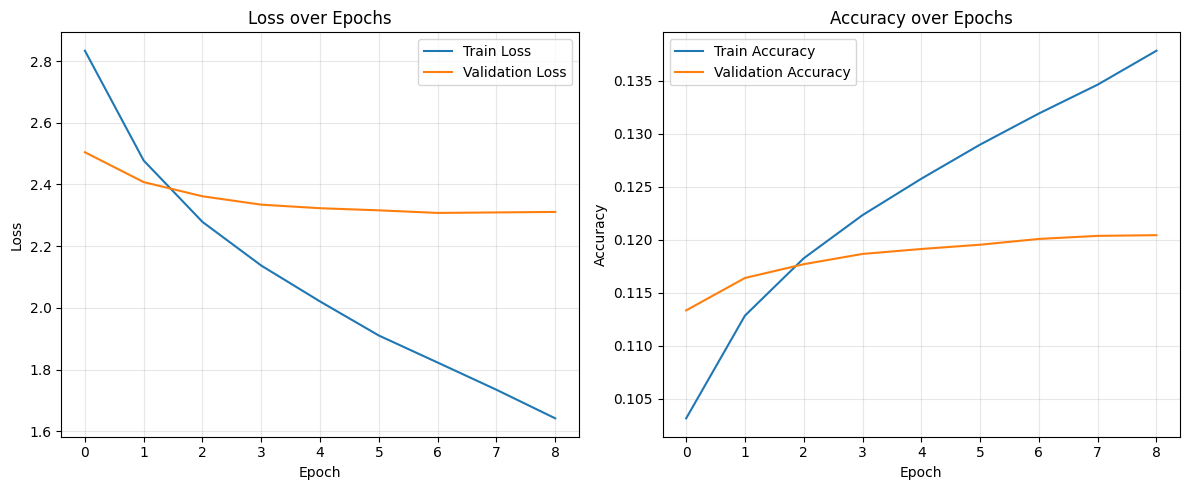

Plot saved to: training_history.png


In [14]:
def plot_history(history):
    hist = history.history
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
    # Loss plot
    axes[0].plot(hist["loss"], label="Train Loss")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="Validation Loss")
    axes[0].set_title("Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
 
    # Accuracy plot (if available)
    acc_key = "accuracy" if "accuracy" in hist else None
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else None
 
    if acc_key:
        axes[1].plot(hist[acc_key], label="Train Accuracy")
        if val_acc_key:
            axes[1].plot(hist[val_acc_key], label="Validation Accuracy")
        axes[1].set_title("Accuracy over Epochs")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "Accuracy metric not available", ha="center")
 
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
    print("Plot saved to: training_history.png")
 
 
plot_history(history)

## **BLEU Metric**

In [15]:
import sacrebleu
from tqdm import tqdm

MAX_LEN = 100
GEN_BATCH_SIZE = 16


def generate_translations(model, tokenizer, source_texts, batch_size=GEN_BATCH_SIZE, max_length=MAX_LEN):
    """Generate translations for a list of source sentences, in batches."""
    predictions = []
    source_texts = list(source_texts)

    for i in tqdm(range(0, len(source_texts), batch_size), desc="Generating translations"):
        batch = source_texts[i : i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        output_ids = model.generate(**inputs, max_length=max_length)
        decoded = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        predictions.extend(decoded)

    return predictions


# ------------------------------------------------------------------
# 1. Generate predictions on the test set
# ------------------------------------------------------------------
predictions = generate_translations(model, tokenizer, X_test)
references = [[ref] for ref in list(y_test)]  # sacrebleu expects list of lists

# ------------------------------------------------------------------
# 2. Compute BLEU
# ------------------------------------------------------------------
bleu = sacrebleu.corpus_bleu(predictions, references)
print(f"BLEU score: {bleu.score:.2f}")
print(bleu)  # shows detailed breakdown (n-gram precisions, brevity penalty, etc.)

# ------------------------------------------------------------------
# 3. Show a few example translations for a sanity check
# ------------------------------------------------------------------
print("\n--- Sample translations ---")
for i in range(min(5, len(predictions))):
    print(f"EN     : {X_test.iloc[i] if hasattr(X_test, 'iloc') else X_test[i]}")
    print(f"Pred AR: {predictions[i]}")
    print(f"Ref  AR: {y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]}")
    print("-" * 40)

Generating translations: 100%|██████████| 152/152 [3:58:21<00:00, 94.09s/it]


BLEU score: 10.92
BLEU = 10.92 90.9/47.6/2.5/1.3 (BP = 1.000 ratio = 1.000 hyp_len = 22 ref_len = 22)

--- Sample translations ---
EN     : digital citizen contributor dalia othman presented research on the arab networked public sphere at the berkman center for internet society where she is a fellow.
Pred AR: قدمت داليا عثمان من مساهمي المواطن الرقمي بحثا عن المجال العام العربي في مركز بيركمان لمجتمع الانترنت حيث هي زميلة فيه.
Ref  AR: قدمت مشاركة المواطن الرقمي داليا عثمان بحثا عن التشبيك العربي الالكتروني المفتوح في مركز بركمان للانترنت والمجتمع وهي زميلة فيه
----------------------------------------
EN     : today we ve just learned that raed al tawil is being subjected to monstrous torture and that he is being held in al khatib state security branch in damascus and that he shall be sent to air force intelligence soon blogs syrian razan ghazzawi about al tawil a red crescent volunteer arrested in syria.
Pred AR: لقد علمنا اليوم ان رعد الطاويل يتعرض للتعذيب الوحشي وانه معتقل في فرع ام